## 1. Import Libraries:

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
#import xgboost as xgb

# import algorithms evaluation libraries:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

# Hyperparameter tuning:
from sklearn.model_selection import GridSearchCV

import matplotlib.pyplot as plt

### 2. Define a Function to Train and Evaluate a Model:

In [2]:
def train_evaluate_model(model, X_train, X_test, y_train, y_test, model_name = "Model"):
    """
    Trains a model, makes predictions, evaluates performance, and plots ROC curve.
    
    Parameters:
        model: sklearn-compatible classifier
        X_train, X_test, y_train, y_test: dataset splits
        model_name: string, name of the model for labeling
    """
    # Train model
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    
    # Probabilities for ROC (if available)
    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    else:  # for SVM with probability=True
        y_pred_proba = model.decision_function(X_test)
    
    # Metrics
    print(f"===== {model_name} =====")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    auc = roc_auc_score(y_test, y_pred_proba)
    print(f"AUC-ROC: {auc:.3f}\n")
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.3f})')


### 3. Prepare Dataset:

In [3]:
# Load the dataset
df = pd.read_csv('creditcard.csv')

# Display the first few rows to understand the structure
print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [4]:
# Separate features (X) and target variable (y)
X = df.drop('Class', axis=1)  
y = df['Class']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# Optional: Standardize features for SVM and Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 4. Define Models:

In [6]:
models = {
    # "Logistic Regression": LogisticRegression(class_weight='balanced', random_state=42),
    "Logistic Regression": LogisticRegression()
    # "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    # "Random Forest": RandomForestClassifier()
    # "SVM": SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42),
    # "GBM": GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)
}

### 5. Train and Evaluate All Models Iteratively:

===== Logistic Regression =====
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.84      0.91     56864
           1       0.01      0.91      0.02        98

    accuracy                           0.84     56962
   macro avg       0.50      0.87      0.47     56962
weighted avg       1.00      0.84      0.91     56962

Confusion Matrix:
[[47684  9180]
 [    9    89]]
AUC-ROC: 0.949



C:\Users\pavle\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\pavle\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\pavle\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names

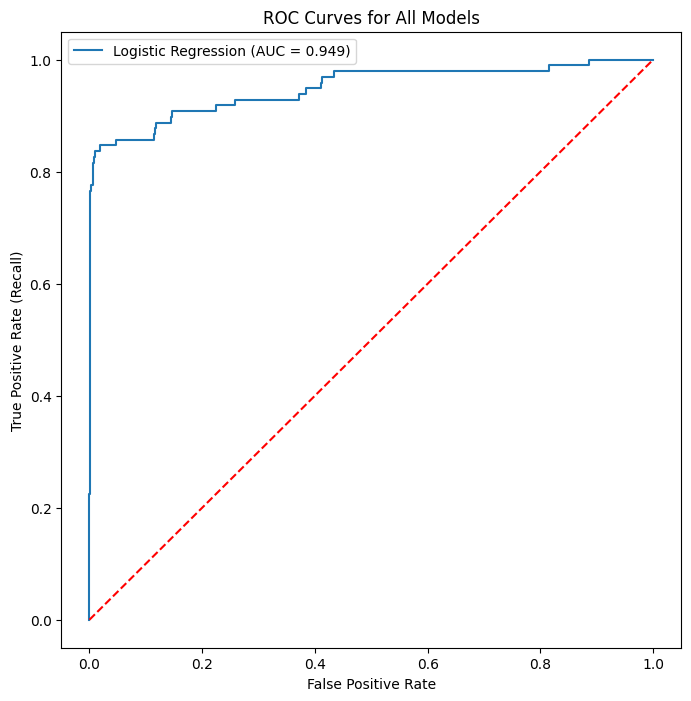

In [7]:
plt.figure(figsize=(8, 8))

for name, model in models.items():
    # Use resampled train data for all models
    train_evaluate_model(model, X_train, X_test_scaled, y_train, y_test, model_name=name)

# Plot formatting
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Random guess line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curves for All Models')
plt.legend()
plt.show()
